In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated
from langchain_groq import ChatGroq
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
import requests
import yfinance as yf
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode,  tools_condition 

from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage,HumanMessage, AIMessage,SystemMessage,ToolMessage
import json
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv

load_dotenv()  
llm = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct", # Or any other valid Groq identifier
    temperature=0.0,
    max_retries=2,
)

In [2]:
from pydantic import BaseModel, Field
from typing import List, Optional, Literal, Dict, Any

# 1. DEFINE THIS FIRST
class FundamentalsReport(BaseModel):
    ticker:         str
    company_name:   Optional[str]
    sector:         Optional[str]
    
    # THE SCRATCHPAD: This saves your API from crashing
    reasoning:      str = Field(description="Show your step-by-step math for the health_score and confidence penalties here BEFORE outputting the final numbers.")
    
    health_score:   float                                            # 0–100
    confidence:     float                                            # 0–1
    recommendation: Literal["Strong Buy", "Buy", "Hold", "Sell", "Strong Sell"]
 
    summary:        str        # 2-3 sentence verdict
    report_summary: str        # longer paragraph: thesis + risk + sector context
 
    positives:      List[str]
    red_flags:      List[str]
 
    key_metrics:    Dict[str, Any]  # PE, EPS, FCF, D/E, margins, ROE, target price …
    sources:        List[str]


In [3]:
def _safe_get(df, row, col):
    if row in df.index:
        return df.loc[row, col]
    return None

@tool
def get_income_statement(ticker: str) -> dict:
    """Fetch revenue, EPS, net income, and margins for the last 3 years."""
    try:
        stock = yf.Ticker(ticker)
        income = stock.financials  # annual income statement
 
        if income.empty:
            return {"error": f"No income statement data found for {ticker}"}
 
        result = {}
        for col in income.columns[:3]:  # last 3 years
            year = str(col.year)
            result[year] = {
                "revenue":     _safe_get(income, "Total Revenue", col),
                "gross_profit":_safe_get(income, "Gross Profit", col),
                "net_income":  _safe_get(income, "Net Income", col),
                "ebitda":      _safe_get(income, "EBITDA", col),
                "eps":         _safe_get(income, "Diluted EPS", col),
            }
 
        return {"income_statement": result, "source": "yfinance"}
 
    except Exception as e:
        return {"error": str(e)}

In [4]:
@tool
def get_balance_sheet(ticker: str) -> dict:
    """Fetch assets, liabilities, debt, and equity from the balance sheet."""
    try:
        stock = yf.Ticker(ticker)
        bs = stock.balance_sheet
 
        if bs.empty:
            return {"error": f"No balance sheet data found for {ticker}"}
 
        col = bs.columns[0]  # most recent year
        return {
            "ticker": ticker,
            "balance_sheet": {
                "total_assets":       _safe_get(bs, "Total Assets", col),
                "total_liabilities":  _safe_get(bs, "Total Liabilities Net Minority Interest", col),
                "total_equity":       _safe_get(bs, "Stockholders Equity", col),
                "total_debt":         _safe_get(bs, "Total Debt", col),
                "cash":               _safe_get(bs, "Cash And Cash Equivalents", col),
            },
            "source": "yfinance"
        }
 
    except Exception as e:
        return {"error": str(e)}

In [5]:
@tool
def get_cash_flow(ticker: str) -> dict:
    """Fetch operating cash flow, free cash flow, and capex."""
    try:
        stock = yf.Ticker(ticker)
        cf = stock.cashflow
 
        if cf.empty:
            return {"error": f"No cash flow data found for {ticker}"}
 
        result = {}
        for col in cf.columns[:3]:  # last 3 years
            year = str(col.year)
            op_cf   = _safe_get(cf, "Operating Cash Flow", col)
            capex   = _safe_get(cf, "Capital Expenditure", col)
            fcf     = (op_cf + capex) if (op_cf and capex) else None  # capex is negative
 
            result[year] = {
                "operating_cash_flow": op_cf,
                "capex":               capex,
                "free_cash_flow":      fcf,
            }
 
        return {"ticker": ticker, "cash_flow": result, "source": "yfinance"}
 
    except Exception as e:
        return {"error": str(e)}

In [6]:
@tool
def get_key_ratios(ticker: str) -> dict:
    """Fetch valuation and efficiency ratios: PE, PB, PS, ROE, debt-to-equity."""
    try:
        stock = yf.Ticker(ticker)
        info  = stock.info
 
        return {
            "ticker": ticker,
            "ratios": {
                "pe_ratio":         info.get("trailingPE"),
                "forward_pe":       info.get("forwardPE"),
                "price_to_book":    info.get("priceToBook"),
                "price_to_sales":   info.get("priceToSalesTrailing12Months"),
                "debt_to_equity":   info.get("debtToEquity"),
                "roe":              info.get("returnOnEquity"),
                "roa":              info.get("returnOnAssets"),
                "gross_margin":     info.get("grossMargins"),
                "operating_margin": info.get("operatingMargins"),
                "profit_margin":    info.get("profitMargins"),
                "current_ratio":    info.get("currentRatio"),
                "revenue_growth":   info.get("revenueGrowth"),
                "earnings_growth":  info.get("earningsGrowth"),
            },
            "source": "yfinance"
        }
 
    except Exception as e:
        return {"error": str(e)}

In [7]:
@tool
def get_company_info(ticker: str) -> dict:
    """Fetch company name, sector, industry, market cap, and analyst targets."""
    try:
        stock = yf.Ticker(ticker)
        info  = stock.info
 
        return {
            "ticker": ticker,
            "company": {
                "name":              info.get("longName"),
                "sector":            info.get("sector"),
                "industry":          info.get("industry"),
                "market_cap":        info.get("marketCap"),
                "employees":         info.get("fullTimeEmployees"),
                "description":       info.get("longBusinessSummary", "")[:400],
            },
            "analyst": {
                "target_price":      info.get("targetMeanPrice"),
                "recommendation":    info.get("recommendationKey"),
                "num_analysts":      info.get("numberOfAnalystOpinions"),
            },
            "source": "yfinance"
        }
 
    except Exception as e:
        return {"error": str(e)}

In [8]:
fundamentals_tools = [get_company_info, get_income_statement, get_balance_sheet, get_cash_flow, get_key_ratios]
fundamentals_tool_node = ToolNode(fundamentals_tools)
fundamentals_llm = llm.bind_tools(fundamentals_tools)

In [9]:
report_writer_llm=llm.with_structured_output(FundamentalsReport)

In [10]:
SYSTEM_PROMPT = """
You are a financial research assistant. Your ONLY job is to gather data for a given company ticker using the tools provided.

You have 5 tools available:
- get_company_info      → sector, market cap, analyst targets
- get_income_statement  → revenue, EPS, margins (3 years)
- get_balance_sheet     → debt, equity, cash
- get_cash_flow         → operating CF, free cash flow, capex
- get_key_ratios        → PE, ROE, debt-to-equity, growth rates

CRITICAL INSTRUCTIONS:
1. You MUST call ALL 5 tools to ensure a complete financial picture before concluding.
2. DO NOT write the final investment report or attempt to summarize the data.
3. DO NOT output JSON. 
4. Just execute the tool calls. Once all tools have successfully returned data, simply say "All data collected."
"""

In [11]:
class FundamentalsState(TypedDict):                                                                                                                                                                  
    messages: Annotated[list[BaseMessage], add_messages]
    ticker: str
    report: FundamentalsReport | None 

In [ ]:
REPORT_SYSTEM_PROMPT = """
You are a financial analyst. Using only the tool data in this conversation, generate the final investment report.
 
SCORING (health_score out of 100):
  +15  Revenue growing YoY          (+5 if flat)
  +20  FCF positive & growing YoY   (+10 if positive only)
  +15  Net margin > 10%             (+7 if 5–10%)
  +15  Debt-to-equity < 1.0         (+7 if 1.0–1.5)
  +15  ROE > 15%                    (+7 if 8–15%)
  +10  PE reasonable for sector
  +10  Analyst target > current price
Award 0 for any criterion where data is missing — add it to data_gaps.
 
RECOMMENDATION:
  ≥75 → "Strong Buy" | 60–74 → "Buy" | 40–59 → "Hold" | 25–39 → "Sell" | <25 → "Strong Sell"
 
CONFIDENCE: start 1.0, subtract 0.10 per missing key metric (PE, FCF, D/E, margins, ROE).
 
FORMAT RULES:
  - CRITICAL: You MUST use the 'reasoning' field to write out your step-by-step math for the health_score and confidence score BEFORE outputting the rest of the JSON.
  - Floats: 2 decimal places (health_score: 75.00, confidence: 0.85)
  - Missing values: null — never omit the key, never guess
  - Percentages: as numbers, not strings (24.3 not "24.3%")
  - FCF / large numbers: raw USD, no abbreviations (92500000000 not "92.5B")
  - Lists: at least 1 item each; empty list [] only if truly none found
  - summary: exactly 2-3 sentences, plain English, no jargon
  - report_summary: 4-6 sentences covering thesis, biggest risk, and peer comparison
"""
def report_node(state: FundamentalsState):
    """
    Report-writing LLM — receives ONLY plain text data, no tool blocks.
    Builds a clean 2-message conversation: system prompt + all tool data.
    """
    # Cleanly extract just the text from the message history to save tokens and confusion
    cleaned_context = "\n".join(
        [f"{msg.type.capitalize()}: {msg.content}" for msg in state["messages"] if msg.content]
    )
 
    clean_messages = [
        SystemMessage(content=REPORT_SYSTEM_PROMPT),
        HumanMessage(content=f"Here is the collected financial data:\n\n{cleaned_context}"),
    ]
 
    response = report_writer_llm.invoke(clean_messages)
    message_output = AIMessage(content=response.model_dump_json())
    
    return {"messages": [message_output], "report": response}

In [13]:
def collect_fundamentals_data_node(state: FundamentalsState):
    response = fundamentals_llm.invoke(state["messages"])
    return {"messages": [response]}

In [14]:
graph = StateGraph(FundamentalsState)
graph.add_node("collect_data", collect_fundamentals_data_node)
graph.add_node("report_writing", report_node)
graph.add_node("fundamentals_tool_node",fundamentals_tool_node)
 
graph.add_edge(START, "collect_data")
graph.add_conditional_edges("collect_data",tools_condition,{"tools": "fundamentals_tool_node", END: "report_writing"})
graph.add_edge("fundamentals_tool_node", "collect_data")

graph.add_edge("report_writing", END)
 
memory = MemorySaver()
 
app = graph.compile(checkpointer=memory)

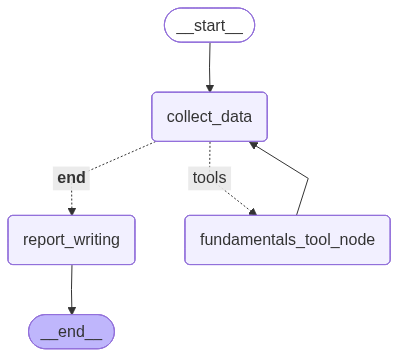

In [15]:
app

In [16]:
def run_fundamentals_agent(ticker: str) -> FundamentalsReport:
    """Run the fundamentals agent for a ticker and return a validated report."""
 
    initial_state = {
        "ticker": ticker,
        "messages": [
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(content=f"Research the fundamentals for ticker: {ticker.upper()}"),
        ],
    }
 
    final_state = app.invoke(initial_state)
 
    # Extract the last message (should be the JSON report)
    last_message = final_state["messages"][-1]
    return last_message

    

In [17]:
b=run_fundamentals_agent("TCS.NS")

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [ ]:
b

{'messages': [SystemMessage(content='\nYou are a financial research assistant. Your ONLY job is to gather data for a given company ticker using the tools provided.\n\nYou have 5 tools available:\n- get_company_info      → sector, market cap, analyst targets\n- get_income_statement  → revenue, EPS, margins (3 years)\n- get_balance_sheet     → debt, equity, cash\n- get_cash_flow         → operating CF, free cash flow, capex\n- get_key_ratios        → PE, ROE, debt-to-equity, growth rates\n\nCRITICAL INSTRUCTIONS:\n1. You MUST call ALL 5 tools to ensure a complete financial picture before concluding.\n2. DO NOT write the final investment report or attempt to summarize the data.\n3. DO NOT output JSON. \n4. Just execute the tool calls. Once all tools have successfully returned data, simply say "All data collected."\n', additional_kwargs={}, response_metadata={}, id='29bd29bd-1b0d-49e6-8243-4cb0afe4a98f'),
  HumanMessage(content='Research the fundamentals for ticker: TCS.NS', additional_kwa

In [ ]:
    "duckduckgo-search>=8.1.1",
    "ipykernel>=7.3.0",
    "langchain>=1.3.10",
    "langchain-community>=0.4.2",
    "langchain-core>=1.4.8",
    "langchain-groq>=1.1.3",
    "langgraph>=1.2.6",
    "pydantic>=2.13.4",
    "python-dotenv>=1.2.2",
    "yfinance>=1.4.1",